In [3]:
%reset -f
import sys
import glob
import os
from os.path import dirname, join as pjoin
# sys.path.append('C:\\jupyter_notebooks\\py_code')
sys.path.append('C:\\Users\Eva\Desktop\ImagingCode')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pickle
import random
import xarray as xr
import pandas as pd
import h5py
import scipy.io as sio
# Load optimizers
import statsmodels.api as sm
from scipy import stats
from scipy.optimize import minimize, basinhopping, curve_fit
import seaborn as sns
from scipy.stats import gaussian_kde

import BD_SciAdv as BD
plt_colors = BD.plt_color_dir()
save_dir = 'C:\\Users\\Eva\\Desktop\\Manuscript2025\\Figures\\4'

# Create save directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

In [4]:
def process_data(data_dir, data_dir2, n_back=15, is_long_to_short=None):
    os.chdir(data_dir)
    list_of_files = glob.glob('*.mat')
    median_tau_list = []
    median_abs_beta_list = []
    
    # Lists to store all tau and beta pairs for correlation analysis
    all_tau_pairs_short = []  # Renamed from all_tau_pairs_ss1
    all_tau_pairs_long = []   # Renamed from all_tau_pairs_ss2
    all_beta_pairs_short = [] # Renamed from all_beta_pairs_ss1
    all_beta_pairs_long = []  # Renamed from all_beta_pairs_ss2
    
    # If is_long_to_short is not provided, try to determine from the directory name
    if is_long_to_short is None:
        is_long_to_short = 'long_to_short' in data_dir
        print(f"Automatically determined data type: {'Long-to-Short' if is_long_to_short else 'Short-to-Long'}")
    
    for file in list_of_files:
        mouse = file[0:5]
        area = file[20:-4]
        date1 = file[6:12]
        date2 = file[13:19]
        session1 = mouse + '_' + date1
        session2 = mouse + '_' + date2
        print(area, session1, session2)
        output_xarray1 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\across_task_matching','sse_{}_{}hist_updated.nc'.format(session1,n_back)))
        output_xarray2 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\across_task_matching','sse_{}_{}hist_updated.nc'.format(session2,n_back)))
        match_ss = pjoin(data_dir, '{}_{}_{}_{}.mat'.format(mouse,date1,date2,area))
        match_ss_contents = sio.loadmat(match_ss,squeeze_me=True)
        Mapping = match_ss_contents['roiMatchData']['allSessionMapping']
        ss1_mapped = Mapping.item()[:,0]-1
        ss2_mapped = Mapping.item()[:,1]-1
        
        out_pd1 = output_xarray1.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd1['tau_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).tau_RC 
        out_pd1['tau_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd1['crit_sig'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd1['crit_sig_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd1['crit_sig_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss1 = out_pd1.loc[ss1_mapped].reset_index()
            
        out_pd2 = output_xarray2.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd2['tau_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).tau_RC
        out_pd2['tau_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd2['crit_sig'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd2['crit_sig_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd2['crit_sig_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss2 = out_pd2.loc[ss2_mapped].reset_index()

        # Explicitly assign short and long sessions based on the is_long_to_short parameter
        if is_long_to_short:
            # For long-to-short data, ss1 is long and ss2 is short
            short_session = matched_ss2
            long_session = matched_ss1
            short_total = len(out_pd2)
            long_total = len(out_pd1)
            print(f"Long-to-Short mapping: session1={session1} (Long), session2={session2} (Short)")
        else:
            # For short-to-long data, ss1 is short and ss2 is long
            short_session = matched_ss1
            long_session = matched_ss2
            short_total = len(out_pd1)
            long_total = len(out_pd2)
            print(f"Short-to-Long mapping: session1={session1} (Short), session2={session2} (Long)")

        
        matched_short_cell = short_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
        matched_long_cell = long_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
        
        matched_sig_index = np.array(matched_short_cell.index)
        matched_short_cell_beta = short_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'beta_RC']
        matched_long_cell_beta = long_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'beta_RC']    

        # Store tau and beta pairs for correlation analysis
        all_tau_pairs_short.append(matched_short_cell)
        all_tau_pairs_long.append(matched_long_cell)
        all_beta_pairs_short.append(matched_short_cell_beta)
        all_beta_pairs_long.append(matched_long_cell_beta)

        median_tau_short = np.median(matched_short_cell)
        median_tau_long = np.median(matched_long_cell)
        median_tau_list.append([median_tau_short, median_tau_long])
        
        median_beta_short = np.median(abs(matched_short_cell_beta))
        median_beta_long = np.median(abs(matched_long_cell_beta))
        median_abs_beta_list.append([median_beta_short, median_beta_long])
    
    
    return median_tau_list, median_abs_beta_list, all_tau_pairs_short, all_tau_pairs_long, all_beta_pairs_short, all_beta_pairs_long

def process_short_to_short_data(data_dir, data_dir2, n_back=15):
    """Process data for short-to-short comparisons.
    
    Args:
        data_dir: Directory containing matching files
        data_dir2: Base directory for imaging data
        n_back: Number of bins for the history model
    """
    os.chdir(data_dir)
    list_of_files = glob.glob('*.mat')
    median_tau_list = []
    median_abs_beta_list = []
    
    # Lists to store all tau and beta pairs for correlation analysis
    all_tau_pairs1 = []
    all_tau_pairs2 = []
    all_beta_pairs1 = []
    all_beta_pairs2 = []
    
    for file in list_of_files:
        mouse = file[0:5]
        area = file[20:-4]
        date1 = file[6:12]
        date2 = file[13:19]
        session1 = mouse + '_' + date1
        session2 = mouse + '_' + date2
        print(f"Short-to-Short mapping: session1={session1}, session2={session2}")
        
        output_xarray1 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\within_task_matching','sse_{}_{}hist_updated.nc'.format(session1,n_back)))
        output_xarray2 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\within_task_matching','sse_{}_{}hist_updated.nc'.format(session2,n_back)))
        match_ss = pjoin(data_dir, '{}_{}_{}_{}.mat'.format(mouse,date1,date2,area))
        match_ss_contents = sio.loadmat(match_ss,squeeze_me=True)
        Mapping = match_ss_contents['roiMatchData']['allSessionMapping']
        ss1_mapped = Mapping.item()[:,0]-1
        ss2_mapped = Mapping.item()[:,1]-1
        
        out_pd1 = output_xarray1.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd1['tau_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).tau_RC 
        out_pd1['tau_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd1['crit_sig'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd1['crit_sig_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd1['crit_sig_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss1 = out_pd1.loc[ss1_mapped].reset_index()
            
        out_pd2 = output_xarray2.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd2['tau_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).tau_RC
        out_pd2['tau_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd2['crit_sig'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd2['crit_sig_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd2['crit_sig_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss2 = out_pd2.loc[ss2_mapped].reset_index()

        matched_cell1 = matched_ss1.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        matched_cell2 = matched_ss2.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        
        matched_cell1_beta = matched_ss1.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'beta_RC']
        matched_cell2_beta = matched_ss2.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'beta_RC']    

        # Store tau and beta pairs for correlation analysis
        all_tau_pairs1.append(matched_cell1)
        all_tau_pairs2.append(matched_cell2)
        all_beta_pairs1.append(matched_cell1_beta)
        all_beta_pairs2.append(matched_cell2_beta)

        median_tau1 = np.median(matched_cell1)
        median_tau2 = np.median(matched_cell2)
        median_tau_list.append([median_tau1, median_tau2])
        
        median_beta1 = np.median(abs(matched_cell1_beta))
        median_beta2 = np.median(abs(matched_cell2_beta))
        median_abs_beta_list.append([median_beta1, median_beta2])
    
    return median_tau_list, median_abs_beta_list, all_tau_pairs1, all_tau_pairs2, all_beta_pairs1, all_beta_pairs2

## Load data

In [5]:
# Process both datasets
data_dir2 = 'C:\\Users\Eva\Desktop\imaging'
n_back = 15

# Lists to store correlations for each session pair
session_tau_correlations = []
session_beta_correlations = []

# Process long-to-short data
data_dir_long_to_short = 'C:\\Users\Eva\Desktop\imaging\matching\long_to_short_RSC'
median_tau_list_long_to_short, median_abs_beta_list_long_to_short, \
    all_tau_pairs_short_long_to_short, all_tau_pairs_long_long_to_short, \
    all_beta_pairs_short_long_to_short, all_beta_pairs_long_long_to_short = process_data(
        data_dir_long_to_short, data_dir2, n_back, is_long_to_short=True)

# Process short-to-long data
data_dir_short_to_long = 'C:\\Users\Eva\Desktop\imaging\matching\short_to_long_RSC'
median_tau_list_short_to_long, median_abs_beta_list_short_to_long, \
    all_tau_pairs_short_short_to_long, all_tau_pairs_long_short_to_long, \
    all_beta_pairs_short_short_to_long, all_beta_pairs_long_short_to_long = process_data(
        data_dir_short_to_long, data_dir2, n_back, is_long_to_short=False)

# Process short-to-short data
data_dir_short_to_short = 'C:\\Users\Eva\Desktop\imaging\matching\short_to_short_RSC'
median_tau_list_short_to_short, median_abs_beta_list_short_to_short, \
    all_tau_pairs_short_to_short1, all_tau_pairs_short_to_short2, \
    all_beta_pairs_short_to_short1, all_beta_pairs_short_to_short2 = process_short_to_short_data(
        data_dir_short_to_short, data_dir2, n_back)

# Calculate short-to-short correlations
short_to_short_tau_correlations = []
short_to_short_beta_correlations = []

for i in range(len(all_tau_pairs_short_to_short1)):
    tau_corr = stats.spearmanr(all_tau_pairs_short_to_short1[i], all_tau_pairs_short_to_short2[i])
    beta_corr = stats.spearmanr(np.abs(all_beta_pairs_short_to_short1[i]), np.abs(all_beta_pairs_short_to_short2[i]))
    short_to_short_tau_correlations.append(tau_corr)
    short_to_short_beta_correlations.append(beta_corr)

RSCl EZ054_240101 EZ054_240211
Long-to-Short mapping: session1=EZ054_240101 (Long), session2=EZ054_240211 (Short)
RSCr EZ054_240102 EZ054_240212
Long-to-Short mapping: session1=EZ054_240102 (Long), session2=EZ054_240212 (Short)
RSCl EZ055_240201 EZ055_240219
Long-to-Short mapping: session1=EZ055_240201 (Long), session2=EZ055_240219 (Short)
RSCl EZ045_230824 EZ045_230915
Short-to-Long mapping: session1=EZ045_230824 (Short), session2=EZ045_230915 (Long)
RSCr EZ050_231225 EZ050_240114
Short-to-Long mapping: session1=EZ050_231225 (Short), session2=EZ050_240114 (Long)
Short-to-Short mapping: session1=EZ039_230411, session2=EZ039_230424
Short-to-Short mapping: session1=EZ045_230821, session2=EZ045_230825
Short-to-Short mapping: session1=EZ049_231118, session2=EZ049_231128
Short-to-Short mapping: session1=EZ050_231219, session2=EZ050_231226
Short-to-Short mapping: session1=EZ051_231226, session2=EZ051_240103


## Session-wise correlation comparisons


Correlation Statistics:
----------------------
Across-task τ correlations:
Mean r = 0.032
Geometric mean p = 3.299e-01

Across-task |β| correlations:
Mean r = 0.490
Geometric mean p = 1.234e-05

Short-to-Short τ correlations:
Mean r = 0.287
Geometric mean p = 1.295e-03

Short-to-Short |β| correlations:
Mean r = 0.518
Geometric mean p = 1.337e-10

Mixed-effects model results for correlation coefficients:
------------------------------------------------------


C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization fai


Tau correlation comparison:
               Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    correlation
No. Observations:      10         Method:                REML       
No. Groups:            7          Scale:                 0.0153     
Min. group size:       1          Log-Likelihood:        3.2850     
Max. group size:       2          Converged:             No         
Mean group size:       1.4                                          
--------------------------------------------------------------------
                            Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                   0.036    0.057 0.619 0.536 -0.077  0.148
condition[T.Short-to-Short] 0.248    0.075 3.321 0.001  0.101  0.394
Group Var                   0.002                                   

p-value for condition effect: 0.0009

Beta correlation comparison:
               Mixed L

C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


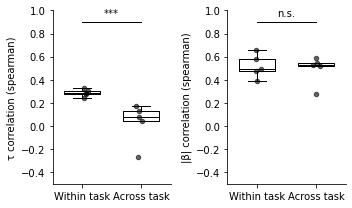

In [6]:
# Calculate and print statistics for correlation boxplots
print("\nCorrelation Statistics:")
print("----------------------")

# Get lists of files for all datasets
os.chdir(data_dir_long_to_short)
list_of_files_long_to_short = glob.glob('*.mat')

os.chdir(data_dir_short_to_long)
list_of_files_short_to_long = glob.glob('*.mat')

os.chdir(data_dir_short_to_short)
list_of_files_short_to_short = glob.glob('*.mat')

# Across-task tau correlations
across_task_tau_correlations = []

# Calculate correlations for long-to-short data
for i in range(len(median_tau_list_long_to_short)):
    tau_corr = stats.spearmanr(all_tau_pairs_short_long_to_short[i], all_tau_pairs_long_long_to_short[i])
    across_task_tau_correlations.append(tau_corr)

# Calculate correlations for short-to-long data
for i in range(len(median_tau_list_short_to_long)):
    tau_corr = stats.spearmanr(all_tau_pairs_short_short_to_long[i], all_tau_pairs_long_short_to_long[i])
    across_task_tau_correlations.append(tau_corr)

across_task_tau_r = np.mean([corr[0] for corr in across_task_tau_correlations])
across_task_tau_p = np.exp(np.mean(np.log([corr[1] for corr in across_task_tau_correlations])))
print(f"Across-task τ correlations:")
print(f"Mean r = {across_task_tau_r:.3f}")
print(f"Geometric mean p = {across_task_tau_p:.3e}")

# Across-task beta correlations
across_task_beta_correlations = []

# Calculate correlations for long-to-short data
for i in range(len(median_abs_beta_list_long_to_short)):
    beta_corr = stats.spearmanr(np.abs(all_beta_pairs_short_long_to_short[i]), np.abs(all_beta_pairs_long_long_to_short[i]))
    across_task_beta_correlations.append(beta_corr)

# Calculate correlations for short-to-long data
for i in range(len(median_abs_beta_list_short_to_long)):
    beta_corr = stats.spearmanr(np.abs(all_beta_pairs_short_short_to_long[i]), np.abs(all_beta_pairs_long_short_to_long[i]))
    across_task_beta_correlations.append(beta_corr)

across_task_beta_r = np.mean([corr[0] for corr in across_task_beta_correlations])
across_task_beta_p = np.exp(np.mean(np.log([corr[1] for corr in across_task_beta_correlations])))
print(f"\nAcross-task |β| correlations:")
print(f"Mean r = {across_task_beta_r:.3f}")
print(f"Geometric mean p = {across_task_beta_p:.3e}")

# Short-to-short correlations
short_to_short_tau_r = np.mean([corr[0] for corr in short_to_short_tau_correlations])
short_to_short_tau_p = np.exp(np.mean(np.log([corr[1] for corr in short_to_short_tau_correlations])))
print(f"\nShort-to-Short τ correlations:")
print(f"Mean r = {short_to_short_tau_r:.3f}")
print(f"Geometric mean p = {short_to_short_tau_p:.3e}")

short_to_short_beta_r = np.mean([corr[0] for corr in short_to_short_beta_correlations])
short_to_short_beta_p = np.exp(np.mean(np.log([corr[1] for corr in short_to_short_beta_correlations])))
print(f"\nShort-to-Short |β| correlations:")
print(f"Mean r = {short_to_short_beta_r:.3f}")
print(f"Geometric mean p = {short_to_short_beta_p:.3e}")

# Prepare data for mixed-effects models comparing correlation coefficients
correlation_data = []

# Add across-task tau correlations
for i, corr in enumerate(across_task_tau_correlations):
    mouse = list_of_files_long_to_short[i][0:5] if i < len(list_of_files_long_to_short) else list_of_files_short_to_long[i-len(list_of_files_long_to_short)][0:5]
    correlation_data.append({
        'mouse': mouse,
        'condition': 'Across-Task',
        'type': 'tau',
        'correlation': corr[0]
    })

# Add short-to-short tau correlations
for i, corr in enumerate(short_to_short_tau_correlations):
    mouse = list_of_files_short_to_short[i][0:5]
    correlation_data.append({
        'mouse': mouse,
        'condition': 'Short-to-Short',
        'type': 'tau',
        'correlation': corr[0]
    })

# Add across-task beta correlations
for i, corr in enumerate(across_task_beta_correlations):
    mouse = list_of_files_long_to_short[i][0:5] if i < len(list_of_files_long_to_short) else list_of_files_short_to_long[i-len(list_of_files_long_to_short)][0:5]
    correlation_data.append({
        'mouse': mouse,
        'condition': 'Across-Task',
        'type': 'beta',
        'correlation': corr[0]
    })

# Add short-to-short beta correlations
for i, corr in enumerate(short_to_short_beta_correlations):
    mouse = list_of_files_short_to_short[i][0:5]
    correlation_data.append({
        'mouse': mouse,
        'condition': 'Short-to-Short',
        'type': 'beta',
        'correlation': corr[0]
    })

# Convert to pandas DataFrame
correlation_df = pd.DataFrame(correlation_data)

# Run mixed-effects models
print("\nMixed-effects model results for correlation coefficients:")
print("------------------------------------------------------")

# Tau correlation model
tau_correlation_model = sm.MixedLM.from_formula(
    "correlation ~ condition", 
    groups=correlation_df[correlation_df['type'] == 'tau']["mouse"], 
    data=correlation_df[correlation_df['type'] == 'tau']
)
tau_correlation_fit = tau_correlation_model.fit()
print("\nTau correlation comparison:")
print(tau_correlation_fit.summary())
tau_correlation_p = tau_correlation_fit.pvalues['condition[T.Short-to-Short]']
print(f"p-value for condition effect: {tau_correlation_p:.4f}")

# Beta correlation model
beta_correlation_model = sm.MixedLM.from_formula(
    "correlation ~ condition", 
    groups=correlation_df[correlation_df['type'] == 'beta']["mouse"], 
    data=correlation_df[correlation_df['type'] == 'beta']
)
beta_correlation_fit = beta_correlation_model.fit()
print("\nBeta correlation comparison:")
print(beta_correlation_fit.summary())
beta_correlation_p = beta_correlation_fit.pvalues['condition[T.Short-to-Short]']
print(f"p-value for condition effect: {beta_correlation_p:.4f}")

# Create boxplots comparing across-task and short-to-short correlations
fig_box, (ax_box1, ax_box2) = plt.subplots(1, 2, figsize=(5, 3))

# Determine significance levels for tau correlations
if tau_correlation_p < 0.001:
    tau_sig_text = "***"
elif tau_correlation_p < 0.01:
    tau_sig_text = "**"
elif tau_correlation_p < 0.05:
    tau_sig_text = "*"
else:
    tau_sig_text = "n.s."

# Determine significance levels for beta correlations
if beta_correlation_p < 0.001:
    beta_sig_text = "***"
elif beta_correlation_p < 0.01:
    beta_sig_text = "**"
elif beta_correlation_p < 0.05:
    beta_sig_text = "*"
else:
    beta_sig_text = "n.s."

# Tau correlation boxplot
tau_data = [[corr[0] for corr in short_to_short_tau_correlations], [corr[0] for corr in across_task_tau_correlations]]
box1 = ax_box1.boxplot(tau_data, 
                widths=0.6, labels=['Within task', 'Across task'], 
                showfliers=False)  # Remove outlier dots

# Change median line color to black
for median in box1['medians']:
    median.set_color('black')

# Add individual data points
for i, data in enumerate(tau_data):
    # Add small random jitter to x position to avoid overlapping points
    x = np.random.normal(i+1, 0.05, size=len(data))
    ax_box1.scatter(x, data, s=20, alpha=0.6, color='black')  # Change color to black

ax_box1.set_ylabel('τ correlation (spearman)')
# Set y-axis limits
ax_box1.set_ylim(-0.5, 1)
ax_box1.spines['top'].set_visible(False)
ax_box1.spines['right'].set_visible(False)

# Add significance indicator for tau correlations - adjust its position for new ylim
ax_box1.plot([1, 2], [0.9, 0.9], 'k-', linewidth=1)
ax_box1.text(1.5, 0.95, tau_sig_text, ha='center', fontsize=10)

# Beta correlation boxplot
beta_data = [[corr[0] for corr in short_to_short_beta_correlations], [corr[0] for corr in across_task_beta_correlations]]
box2 = ax_box2.boxplot(beta_data, 
                widths=0.6, labels=['Within task', 'Across task'],
                showfliers=False)  # Remove outlier dots

# Change median line color to black
for median in box2['medians']:
    median.set_color('black')

# Add individual data points
for i, data in enumerate(beta_data):
    # Add small random jitter to x position to avoid overlapping points
    x = np.random.normal(i+1, 0.05, size=len(data))
    ax_box2.scatter(x, data, s=20, alpha=0.6, color='black')  # Change color to black

ax_box2.set_ylabel('|β| correlation (spearman)')
# Set y-axis limits
ax_box2.set_ylim(-0.5, 1)
ax_box2.spines['top'].set_visible(False)
ax_box2.spines['right'].set_visible(False)

# Add significance indicator for beta correlations - adjust its position for new ylim
ax_box2.plot([1, 2], [0.9, 0.9], 'k-', linewidth=1)
ax_box2.text(1.5, 0.95, beta_sig_text, ha='center', fontsize=10)

plt.tight_layout()

# Save correlation boxplots
plt.savefig(pjoin(save_dir, 'correlation_boxplots.svg'), format='svg', dpi=300, bbox_inches='tight')
plt.savefig(pjoin(save_dir, 'correlation_boxplots.png'), format='png', dpi=300, bbox_inches='tight')
# plt.close(fig_box)

Tau fit: slope = 0.293, intercept = 0.212
Beta fit: slope = 0.546, intercept = 0.056


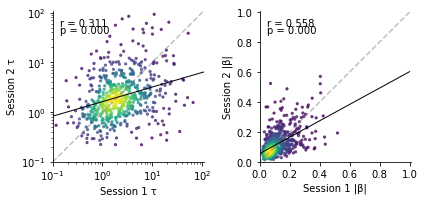

In [8]:
# For tau values
short_to_short_tau1 = []
short_to_short_tau2 = []

# For beta values
short_to_short_beta1 = []
short_to_short_beta2 = []

# Define the number of short-to-short pairs
n_short_to_short = len(median_tau_list_short_to_short)

# Combine all short-to-short data
for i in range(n_short_to_short):
    short_to_short_tau1.extend(all_tau_pairs_short_to_short1[i])
    short_to_short_tau2.extend(all_tau_pairs_short_to_short2[i])
    short_to_short_beta1.extend(all_beta_pairs_short_to_short1[i])
    short_to_short_beta2.extend(all_beta_pairs_short_to_short2[i])

# Convert to numpy arrays
short_to_short_tau1 = np.array(short_to_short_tau1)
short_to_short_tau2 = np.array(short_to_short_tau2)
short_to_short_beta1 = np.array(short_to_short_beta1)
short_to_short_beta2 = np.array(short_to_short_beta2)

# Create correlation plots for short-to-short tau and beta
fig_corr_ss, (ax_corr1_ss, ax_corr2_ss) = plt.subplots(1, 2, figsize=(6, 3))

# Plot tau correlations for short-to-short
tau_corr_ss = stats.spearmanr(short_to_short_tau1, short_to_short_tau2)

# Calculate the point density using kernel density estimation
xy_ss = np.vstack([np.log10(short_to_short_tau1), np.log10(short_to_short_tau2)])
z_ss = gaussian_kde(xy_ss)(xy_ss)

# Sort the points by density, so that the densest points are plotted last
idx_ss = z_ss.argsort()
x_ss, y_ss, z_ss = short_to_short_tau1[idx_ss], short_to_short_tau2[idx_ss], z_ss[idx_ss]

# Create a scatter plot with colors based on density
scatter_ss = ax_corr1_ss.scatter(x_ss, y_ss, c=z_ss, cmap='viridis', s=5, alpha=0.7)
# ax_corr1_ss.plot([0.1, 110], [0.1, 110], color='k')
ax_corr1_ss.set_xscale("log")
ax_corr1_ss.set_yscale("log")
ax_corr1_ss.set_xlim([0.1, 110])
ax_corr1_ss.set_ylim([0.1, 110])
ax_corr1_ss.set_aspect('equal')  # Make plot square
ax_corr1_ss.spines['top'].set_visible(False)
ax_corr1_ss.spines['right'].set_visible(False)
ax_corr1_ss.set_xlabel('Session 1 τ', fontsize=10)
ax_corr1_ss.set_ylabel('Session 2 τ', fontsize=10)

# Add correlation statistics to tau plot
tau_r_text_ss = f"r = {tau_corr_ss[0]:.3f}"
tau_p_text_ss = f"p = {tau_corr_ss[1]:.3f}"
ax_corr1_ss.text(0.05, 0.95, tau_r_text_ss, transform=ax_corr1_ss.transAxes, fontsize=10, verticalalignment='top')
ax_corr1_ss.text(0.05, 0.90, tau_p_text_ss, transform=ax_corr1_ss.transAxes, fontsize=10, verticalalignment='top')


from scipy.stats import linregress

# Tau plot: fit linear regression in log-log space
log_tau1 = np.log10(short_to_short_tau1)
log_tau2 = np.log10(short_to_short_tau2)
slope_tau, intercept_tau, _, _, _ = linregress(log_tau1, log_tau2)
print(f"Tau fit: slope = {slope_tau:.3f}, intercept = {intercept_tau:.3f}")

# Plot dashed grey diagonal line
ax_corr1_ss.plot([0.1, 110], [0.1, 110], linestyle='--', color='grey',alpha=0.5)

# Plot regression line
x_fit = np.linspace(np.log10(0.1), np.log10(110), 100)
y_fit = slope_tau * x_fit + intercept_tau
ax_corr1_ss.plot(10**x_fit, 10**y_fit, color='black', linewidth=1)


################################################################

# Plot beta correlations for short-to-short
beta_corr_ss = stats.spearmanr(np.abs(short_to_short_beta1), np.abs(short_to_short_beta2))

# Calculate the point density using kernel density estimation
xy_beta_ss = np.vstack([np.abs(short_to_short_beta1), np.abs(short_to_short_beta2)])
z_beta_ss = gaussian_kde(xy_beta_ss)(xy_beta_ss)

# Sort the points by density
idx_beta_ss = z_beta_ss.argsort()
x_beta_ss, y_beta_ss, z_beta_ss = np.abs(short_to_short_beta1[idx_beta_ss]), np.abs(short_to_short_beta2[idx_beta_ss]), z_beta_ss[idx_beta_ss]

# Create a scatter plot with colors based on density
scatter_beta_ss = ax_corr2_ss.scatter(x_beta_ss, y_beta_ss, c=z_beta_ss, cmap='viridis', s=5, alpha=0.7)
# ax_corr2_ss.plot([0, 1], [0, 1], color='k', alpha=0.5)
ax_corr2_ss.spines['left'].set_position('zero')
ax_corr2_ss.spines['bottom'].set_position('zero')
ax_corr2_ss.spines['right'].set_color('none')
ax_corr2_ss.spines['top'].set_color('none')
ax_corr2_ss.xaxis.set_ticks_position('bottom')
ax_corr2_ss.yaxis.set_ticks_position('left')
ax_corr2_ss.set_xlim(0, 1.01)
ax_corr2_ss.set_ylim(0, 1.01)
ax_corr2_ss.set_aspect('equal')  # Make plot square
ax_corr2_ss.set_xticks(np.arange(0, 1.01, 0.2))
ax_corr2_ss.set_yticks(np.arange(0, 1.01, 0.2))
ax_corr2_ss.set_xlabel('Session 1 |β|', fontsize=10)
ax_corr2_ss.set_ylabel('Session 2 |β|', fontsize=10)

# Add correlation statistics to beta plot
beta_r_text_ss = f"r = {beta_corr_ss[0]:.3f}"
beta_p_text_ss = f"p = {beta_corr_ss[1]:.3f}"
ax_corr2_ss.text(0.05, 0.95, beta_r_text_ss, transform=ax_corr2_ss.transAxes, fontsize=10, verticalalignment='top')
ax_corr2_ss.text(0.05, 0.90, beta_p_text_ss, transform=ax_corr2_ss.transAxes, fontsize=10, verticalalignment='top')

# Beta plot: fit linear regression (abs values)
beta1_abs = np.abs(short_to_short_beta1)
beta2_abs = np.abs(short_to_short_beta2)
slope_beta, intercept_beta, _, _, _ = linregress(beta1_abs, beta2_abs)
print(f"Beta fit: slope = {slope_beta:.3f}, intercept = {intercept_beta:.3f}")

# Plot dashed grey diagonal line
ax_corr2_ss.plot([0, 1], [0, 1], linestyle='--', color='grey',alpha=0.5)

# Plot regression line
x_fit_beta = np.linspace(0, 1, 100)
y_fit_beta = slope_beta * x_fit_beta + intercept_beta
ax_corr2_ss.plot(x_fit_beta, y_fit_beta, color='black', linewidth=1)


plt.tight_layout()

# Save correlation plots
plt.savefig(pjoin(save_dir, 'short_to_short_tau_beta_correlations.svg'), format='svg', dpi=300, bbox_inches='tight')
plt.savefig(pjoin(save_dir, 'short_to_short_tau_beta_correlations.png'), format='png', dpi=300, bbox_inches='tight')
# plt.close(fig_corr_ss)  # Close the correlation figure

Across-task tau fit: slope = -0.020, intercept = 0.490
Across-task beta fit: slope = 0.453, intercept = 0.061


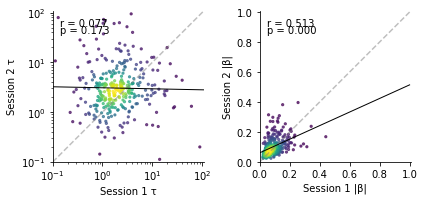

In [10]:
# Create correlation plots for across-task tau and beta
fig_corr_at, (ax_corr1_at, ax_corr2_at) = plt.subplots(1, 2, figsize=(6, 3))

# Combine across-task data
across_task_tau1 = []
across_task_tau2 = []
across_task_beta1 = []
across_task_beta2 = []

# Add long-to-short data
for i in range(len(all_tau_pairs_short_long_to_short)):
    across_task_tau1.extend(all_tau_pairs_short_long_to_short[i])
    across_task_tau2.extend(all_tau_pairs_long_long_to_short[i])
    across_task_beta1.extend(all_beta_pairs_short_long_to_short[i])
    across_task_beta2.extend(all_beta_pairs_long_long_to_short[i])

# Add short-to-long data
for i in range(len(all_tau_pairs_short_short_to_long)):
    across_task_tau1.extend(all_tau_pairs_short_short_to_long[i])
    across_task_tau2.extend(all_tau_pairs_long_short_to_long[i])
    across_task_beta1.extend(all_beta_pairs_short_short_to_long[i])
    across_task_beta2.extend(all_beta_pairs_long_short_to_long[i])

# Convert to numpy arrays
across_task_tau1 = np.array(across_task_tau1)
across_task_tau2 = np.array(across_task_tau2)
across_task_beta1 = np.array(across_task_beta1)
across_task_beta2 = np.array(across_task_beta2)

# Plot tau correlations for across-task
tau_corr_at = stats.spearmanr(across_task_tau1, across_task_tau2)

# Calculate the point density using kernel density estimation
xy_at = np.vstack([np.log10(across_task_tau1), np.log10(across_task_tau2)])
z_at = gaussian_kde(xy_at)(xy_at)

# Sort the points by density, so that the densest points are plotted last
idx_at = z_at.argsort()
x_at, y_at, z_at = across_task_tau1[idx_at], across_task_tau2[idx_at], z_at[idx_at]

# Create a scatter plot with colors based on density
scatter_at = ax_corr1_at.scatter(x_at, y_at, c=z_at, cmap='viridis', s=5, alpha=0.7)
# ax_corr1_at.plot([0.1, 110], [0.1, 110], color='k')
ax_corr1_at.set_xscale("log")
ax_corr1_at.set_yscale("log")
ax_corr1_at.set_xlim([0.1, 110])
ax_corr1_at.set_ylim([0.1, 110])
ax_corr1_at.set_aspect('equal')  # Make plot square
ax_corr1_at.spines['top'].set_visible(False)
ax_corr1_at.spines['right'].set_visible(False)
ax_corr1_at.set_xlabel('Session 1 τ', fontsize=10)
ax_corr1_at.set_ylabel('Session 2 τ', fontsize=10)

# Add correlation statistics to tau plot
tau_r_text_at = f"r = {tau_corr_at[0]:.3f}"
tau_p_text_at = f"p = {tau_corr_at[1]:.3f}"
ax_corr1_at.text(0.05, 0.95, tau_r_text_at, transform=ax_corr1_at.transAxes, fontsize=10, verticalalignment='top')
ax_corr1_at.text(0.05, 0.90, tau_p_text_at, transform=ax_corr1_at.transAxes, fontsize=10, verticalalignment='top')

# Plot dashed grey diagonal
ax_corr1_at.plot([0.1, 110], [0.1, 110], linestyle='--', color='grey',alpha=0.5)

# Linear fit in log-log space
log_tau1_at = np.log10(across_task_tau1)
log_tau2_at = np.log10(across_task_tau2)
slope_tau_at, intercept_tau_at, _, _, _ = linregress(log_tau1_at, log_tau2_at)
print(f"Across-task tau fit: slope = {slope_tau_at:.3f}, intercept = {intercept_tau_at:.3f}")

# Plot the linear fit line
x_fit_log = np.linspace(np.log10(0.1), np.log10(110), 100)
y_fit_log = slope_tau_at * x_fit_log + intercept_tau_at
ax_corr1_at.plot(10**x_fit_log, 10**y_fit_log, color='black', linewidth=1)


#####################################################################################
# Plot beta correlations for across-task
beta_corr_at = stats.spearmanr(np.abs(across_task_beta1), np.abs(across_task_beta2))

# Calculate the point density using kernel density estimation
xy_beta_at = np.vstack([np.abs(across_task_beta1), np.abs(across_task_beta2)])
z_beta_at = gaussian_kde(xy_beta_at)(xy_beta_at)

# Sort the points by density
idx_beta_at = z_beta_at.argsort()
x_beta_at, y_beta_at, z_beta_at = np.abs(across_task_beta1[idx_beta_at]), np.abs(across_task_beta2[idx_beta_at]), z_beta_at[idx_beta_at]

# Create a scatter plot with colors based on density
scatter_beta_at = ax_corr2_at.scatter(x_beta_at, y_beta_at, c=z_beta_at, cmap='viridis', s=5, alpha=0.7)
# ax_corr2_at.plot([0, 1], [0, 1], color='k', alpha=0.5)
ax_corr2_at.spines['left'].set_position('zero')
ax_corr2_at.spines['bottom'].set_position('zero')
ax_corr2_at.spines['right'].set_color('none')
ax_corr2_at.spines['top'].set_color('none')
ax_corr2_at.xaxis.set_ticks_position('bottom')
ax_corr2_at.yaxis.set_ticks_position('left')
ax_corr2_at.set_xlim(0, 1.01)
ax_corr2_at.set_ylim(0, 1.01)
ax_corr2_at.set_aspect('equal')  # Make plot square
ax_corr2_at.set_xticks(np.arange(0, 1.01, 0.2))
ax_corr2_at.set_yticks(np.arange(0, 1.01, 0.2))
ax_corr2_at.set_xlabel('Session 1 |β|', fontsize=10)
ax_corr2_at.set_ylabel('Session 2 |β|', fontsize=10)

# Add correlation statistics to beta plot
beta_r_text_at = f"r = {beta_corr_at[0]:.3f}"
beta_p_text_at = f"p = {beta_corr_at[1]:.3f}"
ax_corr2_at.text(0.05, 0.95, beta_r_text_at, transform=ax_corr2_at.transAxes, fontsize=10, verticalalignment='top')
ax_corr2_at.text(0.05, 0.90, beta_p_text_at, transform=ax_corr2_at.transAxes, fontsize=10, verticalalignment='top')
# Plot dashed grey diagonal
ax_corr2_at.plot([0, 1], [0, 1], linestyle='--', color='grey',alpha=0.5)

# Linear fit in linear space
beta1_abs_at = np.abs(across_task_beta1)
beta2_abs_at = np.abs(across_task_beta2)
slope_beta_at, intercept_beta_at, _, _, _ = linregress(beta1_abs_at, beta2_abs_at)
print(f"Across-task beta fit: slope = {slope_beta_at:.3f}, intercept = {intercept_beta_at:.3f}")

# Plot the linear fit line
x_fit_beta = np.linspace(0, 1, 100)
y_fit_beta = slope_beta_at * x_fit_beta + intercept_beta_at
ax_corr2_at.plot(x_fit_beta, y_fit_beta, color='black', linewidth=1)

plt.tight_layout()

# Save correlation plots
plt.savefig(pjoin(save_dir, 'across_task_tau_beta_correlations.svg'), format='svg', dpi=300, bbox_inches='tight')
plt.savefig(pjoin(save_dir, 'across_task_tau_beta_correlations.png'), format='png', dpi=300, bbox_inches='tight')
# plt.close(fig_corr_at)  # Close the correlation figure